[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Distribusi label awal: label
0    29720
1     2242
Name: count, dtype: int64
Loaded 400000 GloVe vectors
Distribusi setelah SMOTE: [29720 29720]


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 2,000,000 (7.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
743/743 ━━━━━━━━━━━━━━━━━━━━ 185s 232ms/step - accuracy: 0.5081 - auc: 0.5119 - loss: 0.6949 - precision: 0.5069 - recall: 0.5256 - val_accuracy: 0.5556 - val_auc: 0.5711 - val_loss: 0.6912 - val_precision: 0.5621 - val_recall: 0.5385 - learning_rate: 1.0000e-04
Epoch 2/10
743/743 ━━━━━━━━━━━━━━━━━━━━ 185s 215ms/step - accuracy: 0.5316 - auc: 0.5436 - loss: 0.6908 - precision: 0.5340 - recall: 0.5011 - val_accuracy: 0.5119 - val_auc: 0.7393 - val_loss: 0.7438 - val_precision: 0.5082 - val_recall: 0.9975 - learning_rate: 1.0000e-04
Epoch 3/10
743/743 ━━━━━━━━━━━━━━━━━━━━ 201s 214ms/step - accuracy: 0.6440 - auc: 0.6966 - loss: 0.6397 - precision: 0.6427 - recall: 0.6379 - val_accuracy: 0.6078 - val_auc: 0.8106 - val_loss: 0.6932 - val_precision: 0.5642 - val_recall: 0.9775 - learning_rate: 1.0000e-04
Epoch 4/10
743/743 ━━━━━━━━━━━━━━━━━━━━ 202s 214ms/step - accuracy: 0.7156 - auc: 0.7797 - loss: 0.5753 - precision: 0.6989 - recall: 0.7583 - val_accuracy: 0.7163 - val_auc: 0.8

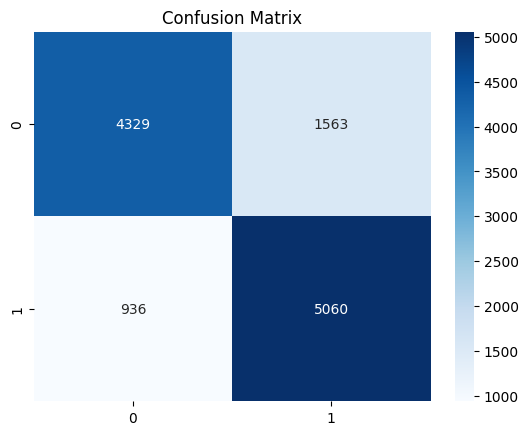

PermutationExplainer explainer: 201it [26:38,  8.03s/it]
/tmp/ipython-input-1-1626223004.py:117: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv.values, features=X_val[:200])


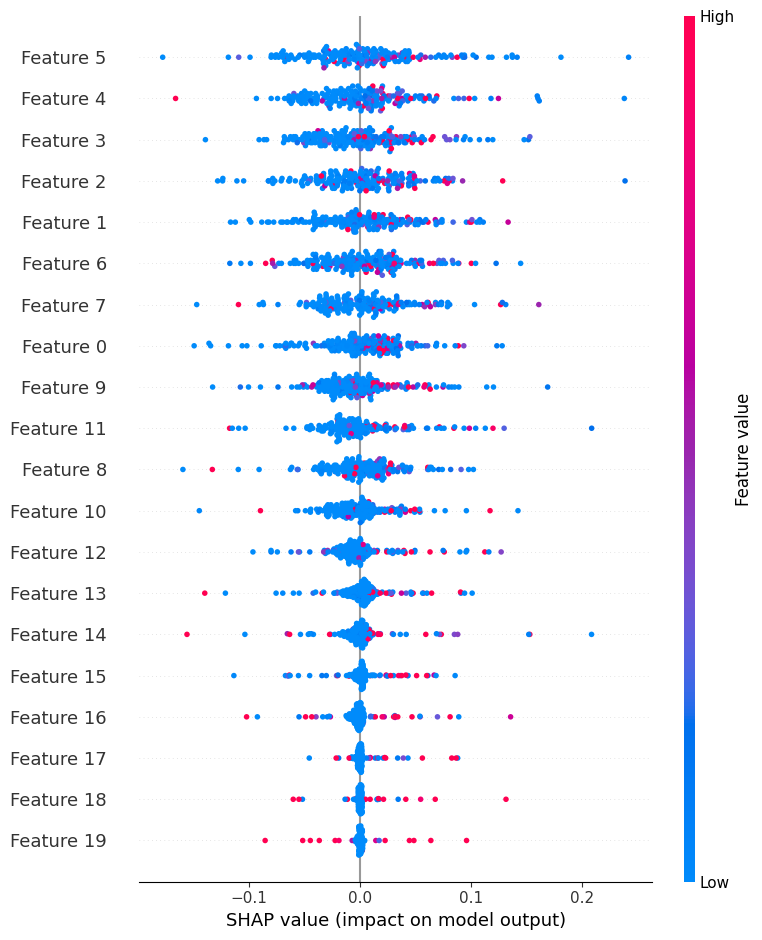

538/538 ━━━━━━━━━━━━━━━━━━━━ 33s 61ms/step
✅ Selesai dan submission.csv telah dibuat.


In [ ]:
# ================== LIBRARY & SETUP ==================
import os, re, nltk, shap, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import Precision, Recall, AUC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score
from imblearn.over_sampling import SMOTE
from google.colab import drive

nltk.download('stopwords')
drive.mount('/content/drive')
base_dir = "/content/drive/MyDrive/Colab Notebooks/research"

# ================== CHAOS DROPOUT FUNCTION ==================
def chaos_dropout_sequence(length, x0=0.7, r=3.9):
    drops, x = [], x0
    for _ in range(length):
        x = r * x * (1 - x)
        drops.append(np.clip(x, 0.2, 0.5))
    return drops

# ================== TEXT CLEANING ==================
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|@\w+|#\w+|[^a-z\s]', '', text)
    return re.sub(r'\s+', ' ', text).strip()

# ================== LOAD GLOVE ==================
def load_glove(path, dim, word_index, vocab_size):
    emb = {}
    with open(path, encoding='utf8') as f:
        for line in f:
            w, *c = line.split()
            emb[w] = np.array(c, dtype='float32')
    print("Loaded", len(emb), "GloVe vectors")
    m = np.zeros((vocab_size, dim))
    for w, idx in word_index.items():
        if idx < vocab_size and w in emb:
            m[idx] = emb[w]
    return m

# ================== DATA LOADING ==================
df = pd.read_csv(os.path.join(base_dir, "train.csv"))
df['tweet'] = df['tweet'].astype(str).apply(clean_text)
print("Distribusi label awal:", df['label'].value_counts())

# ================== TOKENIZER ==================
num_words = 20000
tokenizer = Tokenizer(num_words=num_words, oov_token='<OOV>')
tokenizer.fit_on_texts(df['tweet'])
oov_index = tokenizer.word_index['<OOV>']
sequences = tokenizer.texts_to_sequences(df['tweet'])
sequences = [[t if t < num_words else oov_index for t in seq] for seq in sequences]
X = pad_sequences(sequences, maxlen=50, padding='post')
y = df['label'].values

embedding_matrix = load_glove(os.path.join(base_dir, "glove.6B.100d.txt"), 100, tokenizer.word_index, num_words)

# ================== SMOTE ==================
X_flat = X.reshape(len(X), -1)
sm = SMOTE(random_state=42)
X_sm, y_sm = sm.fit_resample(X_flat, y)
X_sm = X_sm.reshape(-1, 50)
print("Distribusi setelah SMOTE:", np.bincount(y_sm))

X_train, X_val, y_train, y_val = train_test_split(X_sm, y_sm, test_size=0.2, random_state=42)

# ================== MODEL ==================
chaos_rates = chaos_dropout_sequence(2)
model = Sequential([
    Embedding(input_dim=num_words, output_dim=100, weights=[embedding_matrix], input_length=50, trainable=True),
    Bidirectional(LSTM(64, return_sequences=True, dropout=0.3, recurrent_dropout=0.2)),
    LSTM(32, return_sequences=False, dropout=0.2),
    BatchNormalization(),
    Dropout(chaos_rates[0]),
    Dense(32, activation='relu'),
    Dropout(chaos_rates[1]),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.Adam(1e-4),
              metrics=['accuracy', Precision(), Recall(), AUC()])
model.summary()

# ================== TRAIN ==================
es = EarlyStopping(patience=3, restore_best_weights=True)
rlr = ReduceLROnPlateau(patience=2, factor=0.5)
history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                    epochs=10, batch_size=64, callbacks=[es, rlr])

# ================== EVALUATION ==================
val_probs = model.predict(X_val)
best_f1, best_t = 0, 0.5
for t in np.arange(0.3, 0.7, 0.01):
    preds = (val_probs > t).astype(int)
    f = f1_score(y_val, preds)
    if f > best_f1:
        best_f1, best_t = f, t

print(f"\nBest threshold: {best_t:.2f}, F1: {best_f1:.3f}")
val_preds = (val_probs > best_t).astype(int)
print(classification_report(y_val, val_preds))
print("AUC:", roc_auc_score(y_val, val_probs))
sns.heatmap(confusion_matrix(y_val, val_preds), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# ================== SHAP ==================
explainer = shap.Explainer(model, X_val[:200])
sv = explainer(X_val[:200])
shap.summary_plot(sv.values, features=X_val[:200])

# ================== SUBMISSION ==================
test_df = pd.read_csv(os.path.join(base_dir, "test.csv"))
test_df['tweet'] = test_df['tweet'].astype(str).apply(clean_text)
seq = tokenizer.texts_to_sequences(test_df['tweet'])
seq = [[t if t < num_words else oov_index for t in s] for s in seq]
tpad = pad_sequences(seq, maxlen=50, padding='post')
preds = (model.predict(tpad) > best_t).astype(int).flatten()
pd.DataFrame({'id': test_df['id'], 'label': preds}).to_csv(os.path.join(base_dir, "submission.csv"), index=False)
print("✅ Selesai dan submission.csv telah dibuat.")
